In [2]:
#Step1: Data Loading & Inspection

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/Users/anushuabanerjee/Downloads/IoT_Carbon_Footprint_Dataset.csv')

# Inspect structure
print(df.head())

   Person_ID  Energy_Usage_kWh  Transportation_Distance_km      Vehicle_Type  \
0          1         19.977926                   37.364082               Bus   
1          2         47.634287                   33.291210               Bus   
2          3         37.135709                   17.615391  Electric Vehicle   
3          4         30.735607                   60.726667               Car   
4          5          9.488895                   47.662416               Car   

   Smart_Appliance_Usage_hours  Renewable_Energy_Usage_percent Building_Type  \
0                     2.016079                       60.939263    Commercial   
1                     1.668291                        3.890347    Commercial   
2                     7.646111                       61.226034   Residential   
3                    11.627280                        8.966861    Commercial   
4                     6.529934                       71.034424    Commercial   

   Temperature_C  Humidity_percent  Ca

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Person_ID                       10000 non-null  int64  
 1   Energy_Usage_kWh                10000 non-null  float64
 2   Transportation_Distance_km      10000 non-null  float64
 3   Vehicle_Type                    10000 non-null  object 
 4   Smart_Appliance_Usage_hours     10000 non-null  float64
 5   Renewable_Energy_Usage_percent  10000 non-null  float64
 6   Building_Type                   10000 non-null  object 
 7   Temperature_C                   10000 non-null  float64
 8   Humidity_percent                10000 non-null  float64
 9   Carbon_Emission_kgCO2           10000 non-null  float64
dtypes: float64(7), int64(1), object(2)
memory usage: 781.4+ KB
None


In [6]:
print(df.describe())

         Person_ID  Energy_Usage_kWh  Transportation_Distance_km  \
count  10000.00000      10000.000000                10000.000000   
mean    5000.50000         25.719659                   50.452988   
std     2886.89568         13.806246                   28.929455   
min        1.00000          2.000558                    0.015774   
25%     2500.75000         13.823786                   25.394580   
50%     5000.50000         25.641374                   50.589678   
75%     7500.25000         37.520305                   75.647922   
max    10000.00000         49.986448                   99.992483   

       Smart_Appliance_Usage_hours  Renewable_Energy_Usage_percent  \
count                 10000.000000                    10000.000000   
mean                      6.455659                       49.763431   
std                       3.151162                       28.947451   
min                       1.000061                        0.001674   
25%                       3.721966   

In [10]:
#Step 2: Data Preprocessing

In [12]:
#Handle Missing Values (if any)
print(df.isnull().sum())
# If missing values exist, use imputation or removal

Person_ID                         0
Energy_Usage_kWh                  0
Transportation_Distance_km        0
Vehicle_Type                      0
Smart_Appliance_Usage_hours       0
Renewable_Energy_Usage_percent    0
Building_Type                     0
Temperature_C                     0
Humidity_percent                  0
Carbon_Emission_kgCO2             0
dtype: int64


In [14]:
#Encode Categorical Variables
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Vehicle_Type_Encoded'] = le.fit_transform(df['Vehicle_Type'])
df['Building_Type_Encoded'] = le.fit_transform(df['Building_Type'])

# Check the mapping
print("Vehicle Type Encoding:")
print(dict(zip(le.classes_, range(len(le.classes_)))))

print("\nBuilding Type Encoding:")
print(dict(zip(le.classes_, range(len(le.classes_)))))

Vehicle Type Encoding:
{'Commercial': 0, 'Residential': 1}

Building Type Encoding:
{'Commercial': 0, 'Residential': 1}


In [16]:
# Encode Categorical Variables - CORRECTED VERSION
from sklearn.preprocessing import LabelEncoder

# Create SEPARATE encoder instances for each variable
vehicle_encoder = LabelEncoder()
building_encoder = LabelEncoder()

df['Vehicle_Type_Encoded'] = vehicle_encoder.fit_transform(df['Vehicle_Type'])
df['Building_Type_Encoded'] = building_encoder.fit_transform(df['Building_Type'])

# Check the mapping CORRECTLY
print("Vehicle Type Encoding:")
print(dict(zip(vehicle_encoder.classes_, range(len(vehicle_encoder.classes_)))))

print("\nBuilding Type Encoding:")
print(dict(zip(building_encoder.classes_, range(len(building_encoder.classes_)))))

Vehicle Type Encoding:
{'Bus': 0, 'Car': 1, 'Electric Vehicle': 2, 'Walking': 3}

Building Type Encoding:
{'Commercial': 0, 'Residential': 1}


In [18]:
#Step 3: Exploratory Data Analysis (EDA)

In [20]:
#Descriptive Statistics
print(df.describe())

         Person_ID  Energy_Usage_kWh  Transportation_Distance_km  \
count  10000.00000      10000.000000                10000.000000   
mean    5000.50000         25.719659                   50.452988   
std     2886.89568         13.806246                   28.929455   
min        1.00000          2.000558                    0.015774   
25%     2500.75000         13.823786                   25.394580   
50%     5000.50000         25.641374                   50.589678   
75%     7500.25000         37.520305                   75.647922   
max    10000.00000         49.986448                   99.992483   

       Smart_Appliance_Usage_hours  Renewable_Energy_Usage_percent  \
count                 10000.000000                    10000.000000   
mean                      6.455659                       49.763431   
std                       3.151162                       28.947451   
min                       1.000061                        0.001674   
25%                       3.721966   

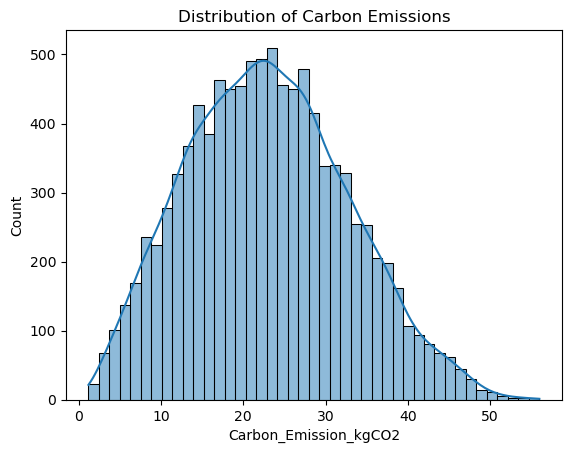

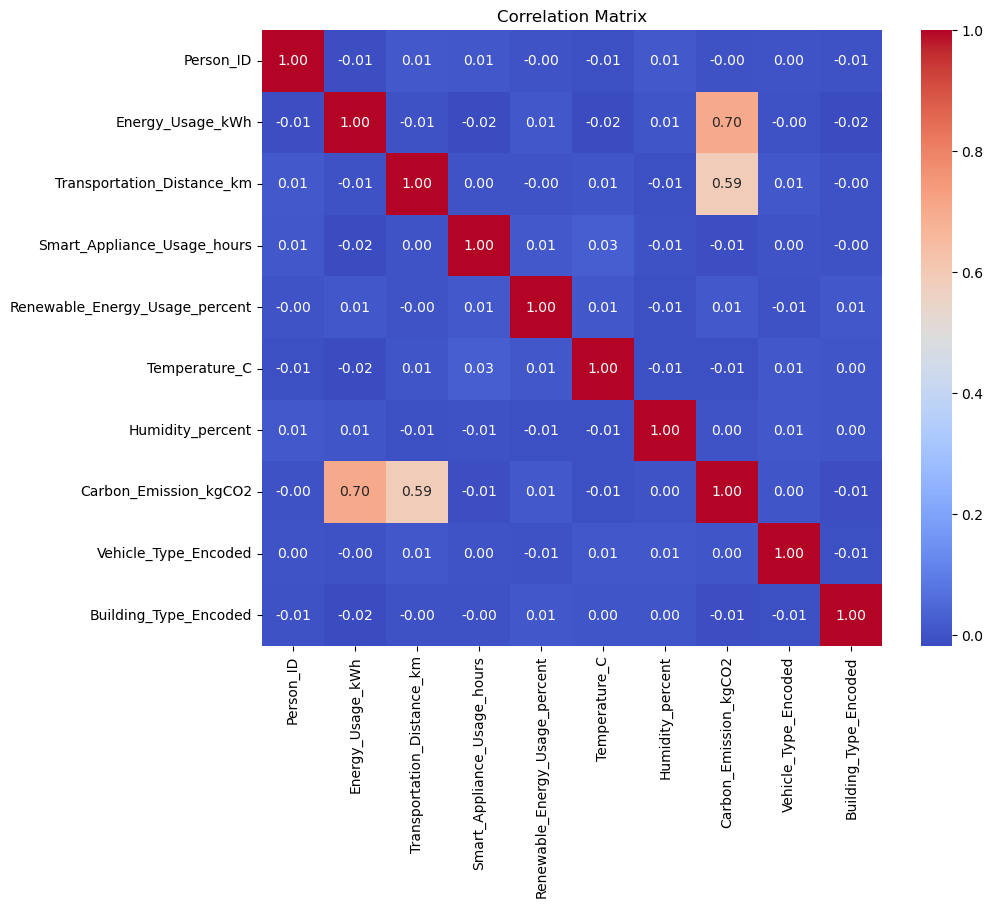

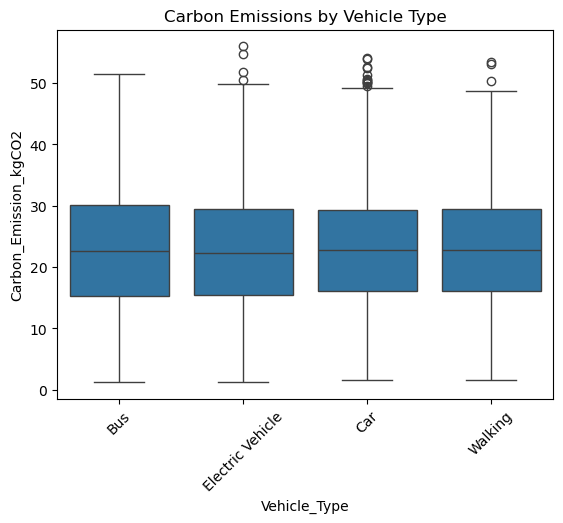

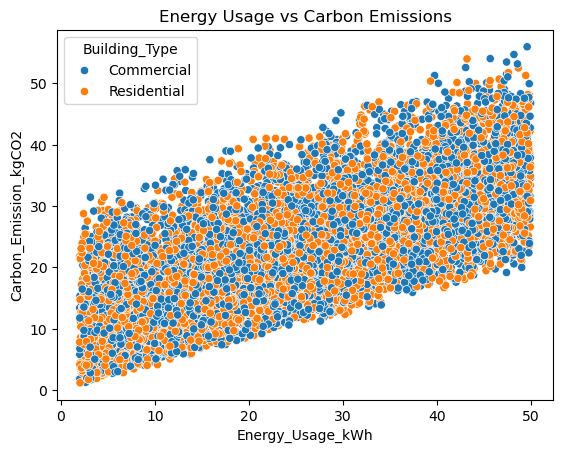

In [22]:
#Visualizations

# Distribution of Carbon Emissions
sns.histplot(df['Carbon_Emission_kgCO2'], kde=True)
plt.title('Distribution of Carbon Emissions')
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# Boxplot: Carbon Emissions by Vehicle Type
sns.boxplot(x='Vehicle_Type', y='Carbon_Emission_kgCO2', data=df)
plt.xticks(rotation=45)
plt.title('Carbon Emissions by Vehicle Type')
plt.show()

# Scatter: Energy Usage vs Carbon Emissions
sns.scatterplot(x='Energy_Usage_kWh', y='Carbon_Emission_kgCO2', hue='Building_Type', data=df)
plt.title('Energy Usage vs Carbon Emissions')
plt.show()

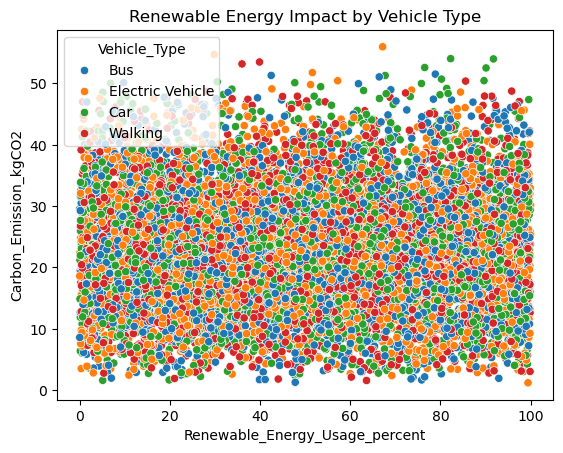

Correlation of interaction term: 0.454


In [24]:
# Investigate the renewable energy paradox
sns.scatterplot(x='Renewable_Energy_Usage_percent', y='Carbon_Emission_kgCO2', hue='Vehicle_Type', data=df)
plt.title('Renewable Energy Impact by Vehicle Type')
plt.show()

# Check interaction between energy usage and renewable energy
df['Energy_Renewable_Interaction'] = df['Energy_Usage_kWh'] * df['Renewable_Energy_Usage_percent']
print(f"Correlation of interaction term: {df['Energy_Renewable_Interaction'].corr(df['Carbon_Emission_kgCO2']):.3f}")

In [26]:
#Step 4: Feature Engineering


In [28]:
#Create New Features
# Effective Energy Usage (example: energy usage adjusted by renewable %)
df['Effective_Energy_Usage'] = df['Energy_Usage_kWh'] * (1 - df['Renewable_Energy_Usage_percent'] / 100)

# Interaction: Transport Distance × Vehicle Type (via encoding)
df['Distance_Vehicle_Interaction'] = df['Transportation_Distance_km'] * df['Vehicle_Type_Encoded']

In [30]:
#Step 5: Predictive Modeling

In [32]:
#Prepare Features & Target
features = [
    'Energy_Usage_kWh',
    'Transportation_Distance_km',
    'Smart_Appliance_Usage_hours',
    'Renewable_Energy_Usage_percent',
    'Temperature_C',
    'Humidity_percent',
    'Vehicle_Type_Encoded',
    'Building_Type_Encoded',
    'Effective_Energy_Usage',
    'Distance_Vehicle_Interaction'
]

X = df[features]
y = df['Carbon_Emission_kgCO2']

In [34]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
#Model 1: Multiple Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Linear Regression Performance:")
print(f"R²: {r2_score(y_test, y_pred_lr):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_lr):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.3f}")

Linear Regression Performance:
R²: 0.854
MAE: 2.956
RMSE: 3.761


In [38]:
#Model 2: Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Performance:")
print(f"R²: {r2_score(y_test, y_pred_rf):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_rf):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.3f}")

Random Forest Performance:
R²: 0.838
MAE: 3.093
RMSE: 3.954


In [40]:
#Step 6: Model Validation


In [42]:
#K-Fold Cross-Validation
from sklearn.model_selection import cross_val_score

cv_scores_lr = cross_val_score(lr, X, y, cv=5, scoring='r2')
cv_scores_rf = cross_val_score(rf, X, y, cv=5, scoring='r2')

print(f"Linear Regression CV R²: {cv_scores_lr.mean():.3f} (±{cv_scores_lr.std():.3f})")
print(f"Random Forest CV R²: {cv_scores_rf.mean():.3f} (±{cv_scores_rf.std():.3f})")

Linear Regression CV R²: 0.849 (±0.003)
Random Forest CV R²: 0.833 (±0.004)


In [43]:
#Step 7: Feature Importance & Interpretation


                          feature  importance
0                Energy_Usage_kWh    0.524275
1      Transportation_Distance_km    0.370497
2     Smart_Appliance_Usage_hours    0.020154
4                   Temperature_C    0.019692
5                Humidity_percent    0.019603
9    Distance_Vehicle_Interaction    0.013963
3  Renewable_Energy_Usage_percent    0.013898
8          Effective_Energy_Usage    0.013435
7           Building_Type_Encoded    0.002410
6            Vehicle_Type_Encoded    0.002074


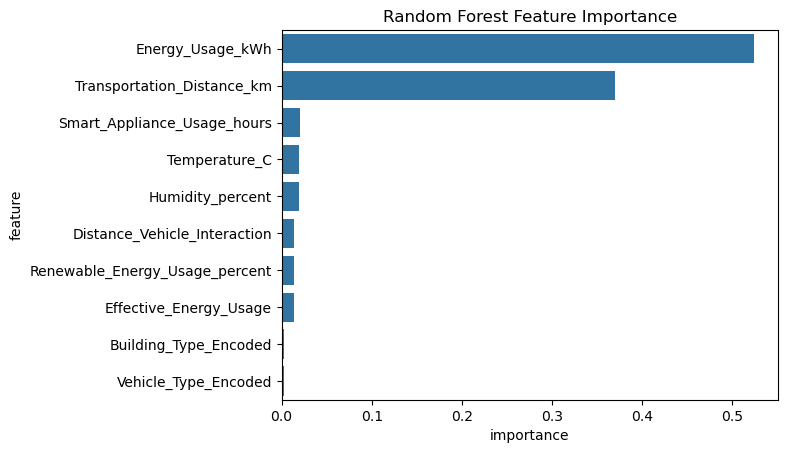

In [46]:
#Random Forest Feature Importance
importance = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(importance)

# Plot
sns.barplot(x='importance', y='feature', data=importance)
plt.title('Random Forest Feature Importance')
plt.show()

In [51]:
#Linear Regression Coefficients
coef_df = pd.DataFrame({
    'feature': features,
    'coefficient': lr.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print(coef_df)

                          feature  coefficient
0                Energy_Usage_kWh     0.499958
1      Transportation_Distance_km     0.199232
7           Building_Type_Encoded     0.033587
8          Effective_Energy_Usage    -0.006082
6            Vehicle_Type_Encoded    -0.004288
2     Smart_Appliance_Usage_hours     0.003510
5                Humidity_percent     0.000720
4                   Temperature_C    -0.000365
9    Distance_Vehicle_Interaction     0.000285
3  Renewable_Energy_Usage_percent     0.000026


In [53]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# Define the parameter grid for Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt']
}

# Initialize Random Forest
rf = RandomForestRegressor(random_state=42)

# Perform Grid Search with Cross-Validation
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Fit the model
print("Starting Grid Search for Random Forest...")
grid_search.fit(X_train, y_train)

# Best parameters and score
print("\nBest Parameters:", grid_search.best_params_)
print("Best Cross-Validation R²:", grid_search.best_score_)

# Test performance with best model
best_rf = grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

print("\nOptimized Random Forest Performance:")
print(f"R²: {r2_score(y_test, y_pred_best_rf):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_best_rf):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best_rf)):.3f}")

Starting Grid Search for Random Forest...
Fitting 5 folds for each of 162 candidates, totalling 810 fits


/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
405 fits failed out of a total of 810.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
369 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/opt/anaconda3/lib/python3.12/site-p


Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Best Cross-Validation R²: 0.8368170032837152

Optimized Random Forest Performance:
R²: 0.843
MAE: 3.072
RMSE: 3.899


In [55]:
# Test different feature subsets based on importance rankings
feature_subsets = {
    'top_2': ['Energy_Usage_kWh', 'Transportation_Distance_km'],
    'top_3': ['Energy_Usage_kWh', 'Transportation_Distance_km', 'Smart_Appliance_Usage_hours'],
    'top_5': ['Energy_Usage_kWh', 'Transportation_Distance_km', 'Smart_Appliance_Usage_hours', 
              'Temperature_C', 'Humidity_percent'],
    'energy_transport_only': ['Energy_Usage_kWh', 'Transportation_Distance_km'],
    'all_features': features  # Your original feature set
}

# Test each subset with Linear Regression
from sklearn.linear_model import LinearRegression

results = {}

for subset_name, feature_list in feature_subsets.items():
    print(f"\nTesting feature subset: {subset_name}")
    print(f"Features: {feature_list}")
    
    # Prepare data
    X_subset = df[feature_list]
    X_train_sub, X_test_sub, y_train_sub, y_test_sub = train_test_split(
        X_subset, y, test_size=0.2, random_state=42
    )
    
    # Linear Regression
    lr_subset = LinearRegression()
    lr_subset.fit(X_train_sub, y_train_sub)
    y_pred_lr_sub = lr_subset.predict(X_test_sub)
    
    # Calculate metrics
    r2 = r2_score(y_test_sub, y_pred_lr_sub)
    mae = mean_absolute_error(y_test_sub, y_pred_lr_sub)
    rmse = np.sqrt(mean_squared_error(y_test_sub, y_pred_lr_sub))
    
    results[subset_name] = {
        'r2': r2,
        'mae': mae, 
        'rmse': rmse,
        'features': feature_list,
        'num_features': len(feature_list)
    }
    
    print(f"R²: {r2:.3f}, MAE: {mae:.3f}, RMSE: {rmse:.3f}")

# Compare results
print("\n" + "="*50)
print("FEATURE SUBSET COMPARISON")
print("="*50)

for subset_name, metrics in sorted(results.items(), key=lambda x: x[1]['r2'], reverse=True):
    print(f"{subset_name:.<20} R²: {metrics['r2']:.3f} | Features: {metrics['num_features']}")


Testing feature subset: top_2
Features: ['Energy_Usage_kWh', 'Transportation_Distance_km']
R²: 0.854, MAE: 2.956, RMSE: 3.762

Testing feature subset: top_3
Features: ['Energy_Usage_kWh', 'Transportation_Distance_km', 'Smart_Appliance_Usage_hours']
R²: 0.854, MAE: 2.956, RMSE: 3.762

Testing feature subset: top_5
Features: ['Energy_Usage_kWh', 'Transportation_Distance_km', 'Smart_Appliance_Usage_hours', 'Temperature_C', 'Humidity_percent']
R²: 0.854, MAE: 2.956, RMSE: 3.762

Testing feature subset: energy_transport_only
Features: ['Energy_Usage_kWh', 'Transportation_Distance_km']
R²: 0.854, MAE: 2.956, RMSE: 3.762

Testing feature subset: all_features
Features: ['Energy_Usage_kWh', 'Transportation_Distance_km', 'Smart_Appliance_Usage_hours', 'Renewable_Energy_Usage_percent', 'Temperature_C', 'Humidity_percent', 'Vehicle_Type_Encoded', 'Building_Type_Encoded', 'Effective_Energy_Usage', 'Distance_Vehicle_Interaction']
R²: 0.854, MAE: 2.956, RMSE: 3.761

FEATURE SUBSET COMPARISON
all_fea